In [1]:
import numpy as np
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

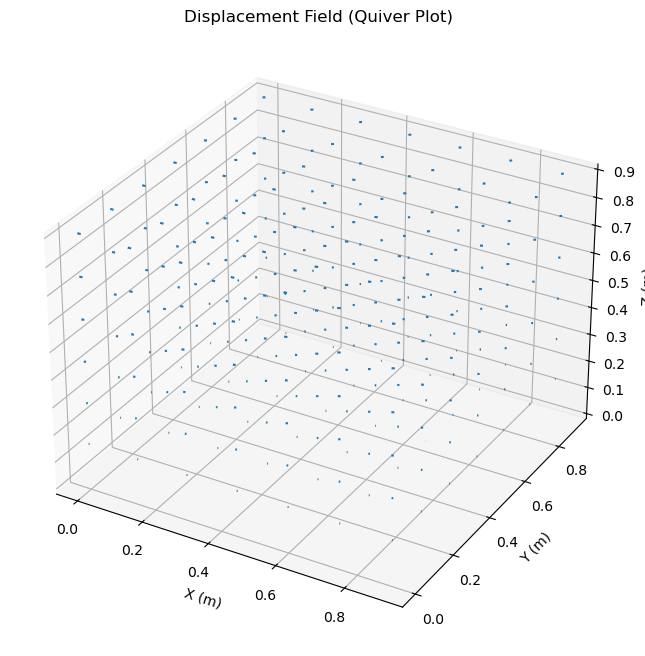

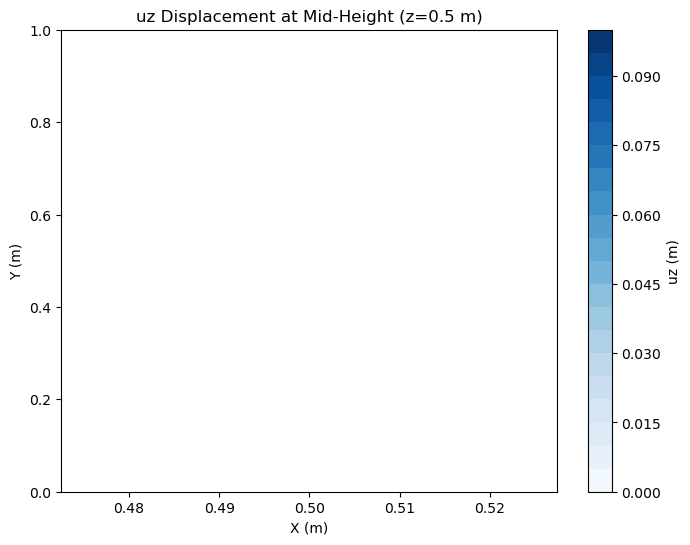

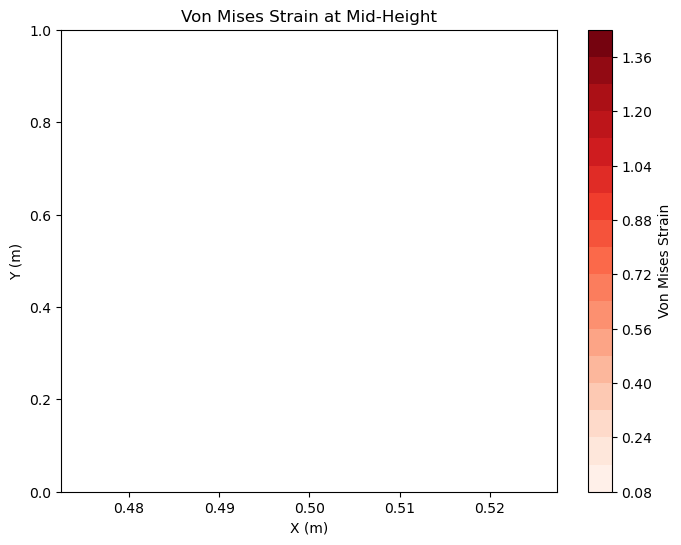

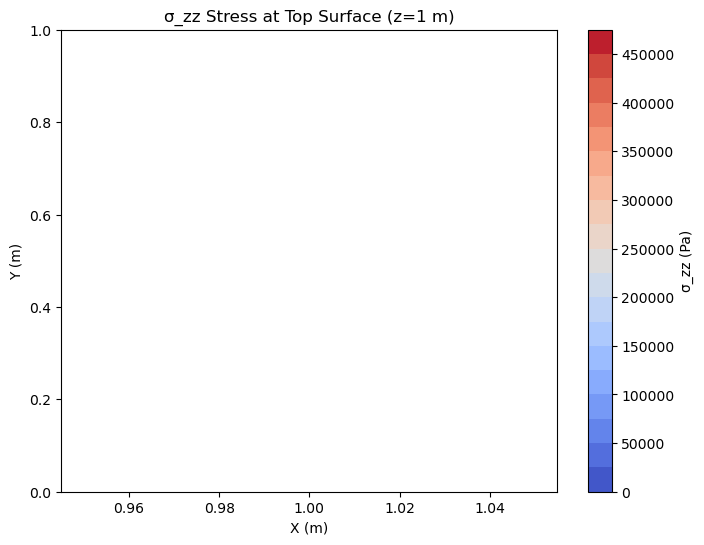

In [2]:
# Parameters
N = 21  # Number of grid points per direction (odd for better centering)
L = 1.0
h = L / (N - 1)
E = 3e6  # Pa
nu = 0.4
lamb = E * nu / ((1 + nu) * (1 - 2 * nu))
mu = E / (2 * (1 + nu))
M = N * N * N
dof = 3 * M
rows = []
cols = []
vals = []
b = np.zeros(dof)

def get_index(i, j, k):
    return i + j * N + k * N * N

def get_mirrored_pos(i, j, k, di, dj, dk):
    ni = i + di
    if ni < 0:
        ni = -ni
    elif ni >= N:
        ni = 2 * (N - 1) - ni
    nj = j + dj
    if nj < 0:
        nj = -nj
    elif nj >= N:
        nj = 2 * (N - 1) - nj
    nk = k + dk
    if nk < 0:
        nk = -nk
    elif nk >= N:
        nk = 2 * (N - 1) - nk
    return ni, nj, nk

def add_dirichlet(m, d, value):
    dd = 3 * m + d
    rows.append(dd)
    cols.append(dd)
    vals.append(1.0)
    b[dd] = value

def add_momentum_eq(i, j, k, comp):
    m = get_index(i, j, k)
    dd_row = 3 * m + comp
    # Lap self term: mu * (-6 / h^2)
    rows.append(dd_row)
    cols.append(dd_row)
    vals.append(mu * (-6.0 / h**2))
    # Lap neighbor terms
    for dir_idx in range(3):
        if dir_idx == 0:
            base_var = i
            fixed1, fixed2 = j, k
            delta_pos = 1
            delta_neg = -1
        elif dir_idx == 1:
            base_var = j
            fixed1, fixed2 = i, k
            delta_pos = 1
            delta_neg = -1
        else:
            base_var = k
            fixed1, fixed2 = i, j
            delta_pos = 1
            delta_neg = -1
        has_m = base_var > 0
        has_p = base_var < N - 1
        coeff_nb = mu / h**2
        # Positive neighbor
        if has_p:
            if dir_idx == 0:
                m_p = get_index(i + 1, fixed1, fixed2)
            elif dir_idx == 1:
                m_p = get_index(fixed1, j + 1, fixed2)
            else:
                m_p = get_index(fixed1, fixed2, k + 1)
            rows.append(dd_row)
            cols.append(3 * m_p + comp)
            vals.append(coeff_nb)
            if not has_m:
                rows.append(dd_row)
                cols.append(3 * m_p + comp)
                vals.append(coeff_nb)
        # Negative neighbor
        if has_m:
            if dir_idx == 0:
                m_m = get_index(i - 1, fixed1, fixed2)
            elif dir_idx == 1:
                m_m = get_index(fixed1, j - 1, fixed2)
            else:
                m_m = get_index(fixed1, fixed2, k - 1)
            rows.append(dd_row)
            cols.append(3 * m_m + comp)
            vals.append(coeff_nb)
            if not has_p:
                rows.append(dd_row)
                cols.append(3 * m_m + comp)
                vals.append(coeff_nb)
    # Grad div term: (lamb + mu) * partial_comp (div u)
    lm = lamb + mu
    h1 = 2 * h
    coeff_p_div = lm / h1
    coeff_m_div = -lm / h1
    # Plus position for div
    di_p = 1 if comp == 0 else 0
    dj_p = 1 if comp == 1 else 0
    dk_p = 1 if comp == 2 else 0
    i_p, j_p, k_p = get_mirrored_pos(i, j, k, di_p, dj_p, dk_p)
    # Minus position for div
    di_m = -1 if comp == 0 else 0
    dj_m = -1 if comp == 1 else 0
    dk_m = -1 if comp == 2 else 0
    i_m, j_m, k_m = get_mirrored_pos(i, j, k, di_m, dj_m, dk_m)
    # For each div position, add its contributions
    for div_i, div_j, div_k, div_coeff in [(i_p, j_p, k_p, coeff_p_div), (i_m, j_m, k_m, coeff_m_div)]:
        # ux contribution (d/dx)
        c_plus_u = div_coeff / h1 * 1.0  # Wait, no: the inner first der is already / (2h), but wait, in code above I set c_plus_u = div_coeff / h1, but div_coeff = lm / (2h), wait no.
        # Correction: the partial_comp div = (div_p - div_m) / (2 h)
        # div = sum (u_{comp+1} - u_{comp-1}) / (2 h)
        # So overall / (2h) for partial_comp, / (2h) for each partial in div.
        # But in my code, coeff_p_div = lm / (2 h)
        # Then for the inner, c_plus_u = div_coeff * (1 / (2 h) )
        # Wait, yes, I have c_plus_u = div_coeff / h1 , but h1=2*h, so / (2 h)
        # Yes, div_coeff / (2 h) * 1 for the + in inner der.
        # Wait, the inner der coeff for + is +1/(2h), so total for that u: lm / (2h) * 1/(2h) = lm / (4 h^2)
        # But that's correct for the discretization.
        # Yes, the code has c_plus_u = div_coeff / h1 , but h1=2*h, div_coeff = lm/(2h), so lm/(2h) / (2h) = lm / (4 h^2)
        # Yes, and for second order central, the term is correct.
        # Now, implement as is.
        # ux d/dx
        iu_p, ju_p, ku_p = get_mirrored_pos(div_i, div_j, div_k, 1, 0, 0)
        m_ux_p = get_index(iu_p, ju_p, ku_p)
        rows.append(dd_row)
        cols.append(3 * m_ux_p + 0)
        vals.append(div_coeff * (1 / h1))  # +1/(2h) * div_coeff
        iu_m, ju_m, ku_m = get_mirrored_pos(div_i, div_j, div_k, -1, 0, 0)
        m_ux_m = get_index(iu_m, ju_m, ku_m)
        rows.append(dd_row)
        cols.append(3 * m_ux_m + 0)
        vals.append(div_coeff * (-1 / h1))  # -1/(2h)
        # uy d/dy
        iuy_p, juy_p, kuy_p = get_mirrored_pos(div_i, div_j, div_k, 0, 1, 0)
        m_uy_p = get_index(iuy_p, juy_p, kuy_p)
        rows.append(dd_row)
        cols.append(3 * m_uy_p + 1)
        vals.append(div_coeff * (1 / h1))
        iuy_m, juy_m, kuy_m = get_mirrored_pos(div_i, div_j, div_k, 0, -1, 0)
        m_uy_m = get_index(iuy_m, juy_m, kuy_m)
        rows.append(dd_row)
        cols.append(3 * m_uy_m + 1)
        vals.append(div_coeff * (-1 / h1))
        # uz d/dz
        iuz_p, juz_p, kuz_p = get_mirrored_pos(div_i, div_j, div_k, 0, 0, 1)
        m_uz_p = get_index(iuz_p, juz_p, kuz_p)
        rows.append(dd_row)
        cols.append(3 * m_uz_p + 2)
        vals.append(div_coeff * (1 / h1))
        iuz_m, juz_m, kuz_m = get_mirrored_pos(div_i, div_j, div_k, 0, 0, -1)
        m_uz_m = get_index(iuz_m, juz_m, kuz_m)
        rows.append(dd_row)
        cols.append(3 * m_uz_m + 2)
        vals.append(div_coeff * (-1 / h1))

# Main assembly loop
half = (N - 1) // 2
for k in range(N):
    for j in range(N):
        for i in range(N):
            m = get_index(i, j, k)
            on_bottom = (k == 0)
            on_top = (k == N - 1)
            loaded = on_top and (i <= half) and (j <= half)
            prescribed = [False, False, False]
            values = [0.0, 0.0, 0.0]
            if on_bottom:
                prescribed = [True, True, True]
                values = [0.0, 0.0, 0.0]
            if on_top and loaded:
                prescribed[2] = True
                values[2] = 0.1
            # Add Dirichlet
            for d in range(3):
                if prescribed[d]:
                    add_dirichlet(m, d, values[d])
            # Add momentum for non-prescribed dofs
            for d in range(3):
                if not prescribed[d]:
                    add_momentum_eq(i, j, k, d)

# Build and solve system
A = coo_matrix((vals, (rows, cols)), shape=(dof, dof)).tocsr()
U = spsolve(A, b)

# Reshape to fields (note: shape (Nx, Ny, Nz) for i=x, j=y, k=z
ux = np.zeros((N, N, N))
uy = np.zeros((N, N, N))
uz = np.zeros((N, N, N))
for k in range(N):
    for j in range(N):
        for i in range(N):
            m = get_index(i, j, k)
            ux[i, j, k] = U[3 * m]
            uy[i, j, k] = U[3 * m + 1]
            uz[i, j, k] = U[3 * m + 2]

# Compute strains using np.gradient (central diff interior, one-sided boundaries)
dudx, dudy, dudz = np.gradient(ux, h, axis=(0, 1, 2))
dvdx, dvdy, dvdz = np.gradient(uy, h, axis=(0, 1, 2))
dwdx, dwdy, dwdz = np.gradient(uz, h, axis=(0, 1, 2))

exx = dudx
eyy = dvdy
ezz = dwdz
exy = 0.5 * (dudy + dvdx)
exz = 0.5 * (dudz + dwdx)
eyz = 0.5 * (dvdz + dwdy)

# Compute stresses
trace = exx + eyy + ezz
sxx = lamb * trace + 2 * mu * exx
syy = lamb * trace + 2 * mu * eyy
szz = lamb * trace + 2 * mu * ezz
sxy = 2 * mu * exy
sxz = 2 * mu * exz
syz = 2 * mu * eyz

# 3D Visualizations
X, Y, Z = np.meshgrid(np.linspace(0, L, N), np.linspace(0, L, N), np.linspace(0, L, N), indexing='ij')

# 1. Displacement field: 3D quiver plot (subsampled)
fig1 = plt.figure(figsize=(10, 8))
ax1 = fig1.add_subplot(111, projection='3d')
step = max(1, N // 6)
idx = slice(None, None, step)
ax1.quiver(X[idx, idx, idx], Y[idx, idx, idx], Z[idx, idx, idx],
           ux[idx, idx, idx], uy[idx, idx, idx], uz[idx, idx, idx],
           length=0.05, arrow_length_ratio=0.1, normalize=False)
ax1.set_xlabel('X (m)')
ax1.set_ylabel('Y (m)')
ax1.set_zlabel('Z (m)')
ax1.set_title('Displacement Field (Quiver Plot)')
plt.show()

# 2. uz displacement slice at mid-height
fig2, ax2 = plt.subplots(figsize=(8, 6))
mid = N // 2
im2 = ax2.contourf(X[mid, :, :], Y[mid, :, :], uz[mid, :, :], levels=20, cmap='Blues')
plt.colorbar(im2, ax=ax2, label='uz (m)')
ax2.set_xlabel('X (m)')
ax2.set_ylabel('Y (m)')
ax2.set_title('uz Displacement at Mid-Height (z=0.5 m)')
plt.show()

# 3. Strain field example: von Mises strain (simplified visualization via ezz slice)
fig3, ax3 = plt.subplots(figsize=(8, 6))
von_mises_strain = np.sqrt(2 * (exx**2 + eyy**2 + ezz**2 - exx*eyy - exx*ezz - eyy*ezz) + 12 * (exy**2 + exz**2 + eyz**2))
im3 = ax3.contourf(X[mid, :, :], Y[mid, :, :], von_mises_strain[mid, :, :], levels=20, cmap='Reds')
plt.colorbar(im3, ax=ax3, label='Von Mises Strain')
ax3.set_xlabel('X (m)')
ax3.set_ylabel('Y (m)')
ax3.set_title('Von Mises Strain at Mid-Height')
plt.show()

# 4. Stress field example: szz slice at top
fig4, ax4 = plt.subplots(figsize=(8, 6))
top = N - 1
im4 = ax4.contourf(X[top, :, :], Y[top, :, :], szz[top, :, :], levels=20, cmap='coolwarm')
plt.colorbar(im4, ax=ax4, label='σ_zz (Pa)')
ax4.set_xlabel('X (m)')
ax4.set_ylabel('Y (m)')
ax4.set_title('σ_zz Stress at Top Surface (z=1 m)')
plt.show()


In [3]:
# 先补充必要的库导入（原代码可能遗漏，需先添加）
import numpy as np
from scipy.sparse import coo_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt

# -------------------------- 原代码所有内容（此处省略，保留原代码不变） --------------------------
# ... 原代码的参数定义、函数定义、组装矩阵、求解、计算应变/应力、可视化等 ...

# -------------------------- 打印Z=1（top）的uz数据 --------------------------
# 1. 定义Z=1对应的网格索引（与原代码一致）
top = N - 1  # Z=1m 对应k=N-1
# 2. 提取Z=1的uz数据
uz_z1 = uz[:, :, top]  # 形状为(N, N)，i-x轴，j-y轴，对应Z=1平面上所有点的竖向位移

# 3. 打印数据（多种方式可选）
print("=" * 50)
print(f"Z=1m（顶部）的uz位移数据（形状：{uz_z1.shape}，i-x，j-y）：")
print("=" * 50)

# 方式1：直接完整打印（适合N较小时，如N=21）
print("完整uz数据（Z=1）：")
print(uz_z1)

# 方式2：格式化打印（保留4位小数，更清晰）
print("\n格式化uz数据（Z=1，保留4位小数）：")
np.set_printoptions(precision=4, suppress=True)  # 抑制科学计数法，保留4位小数
print(uz_z1)

# 方式3：打印关键信息（最大值、最小值、非零区域等，辅助分析）
print("\nZ=1的uz数据关键信息：")
print(f"最大值：{np.max(uz_z1):.6f} m")
print(f"最小值：{np.min(uz_z1):.6f} m")
print(f"非零区域（对应预设位移0.1m）：{np.where(uz_z1 == 0.1)}")
print("=" * 50)

Z=1m（顶部）的uz位移数据（形状：(21, 21)，i-x，j-y）：
完整uz数据（Z=1）：
[[0.1        0.1        0.1        0.1        0.1        0.1
  0.1        0.1        0.1        0.1        0.1        0.06911343
  0.05338089 0.04350042 0.03655583 0.03140573 0.02754677 0.02471724
  0.02277673 0.02164363 0.02127637]
 [0.1        0.1        0.1        0.1        0.1        0.1
  0.1        0.1        0.1        0.1        0.1        0.06906611
  0.05331579 0.04342918 0.03648412 0.03133635 0.02748091 0.02465501
  0.02271754 0.02158644 0.0212199 ]
 [0.1        0.1        0.1        0.1        0.1        0.1
  0.1        0.1        0.1        0.1        0.1        0.0689253
  0.05311956 0.04321308 0.03626584 0.03112478 0.02727984 0.02446487
  0.02253657 0.02141149 0.02104704]
 [0.1        0.1        0.1        0.1        0.1        0.1
  0.1        0.1        0.1        0.1        0.1        0.06868131
  0.05278075 0.04284177 0.03589281 0.03076517 0.02693973 0.02414452
  0.02223255 0.02111809 0.02075731]
 [0.1        0.1  

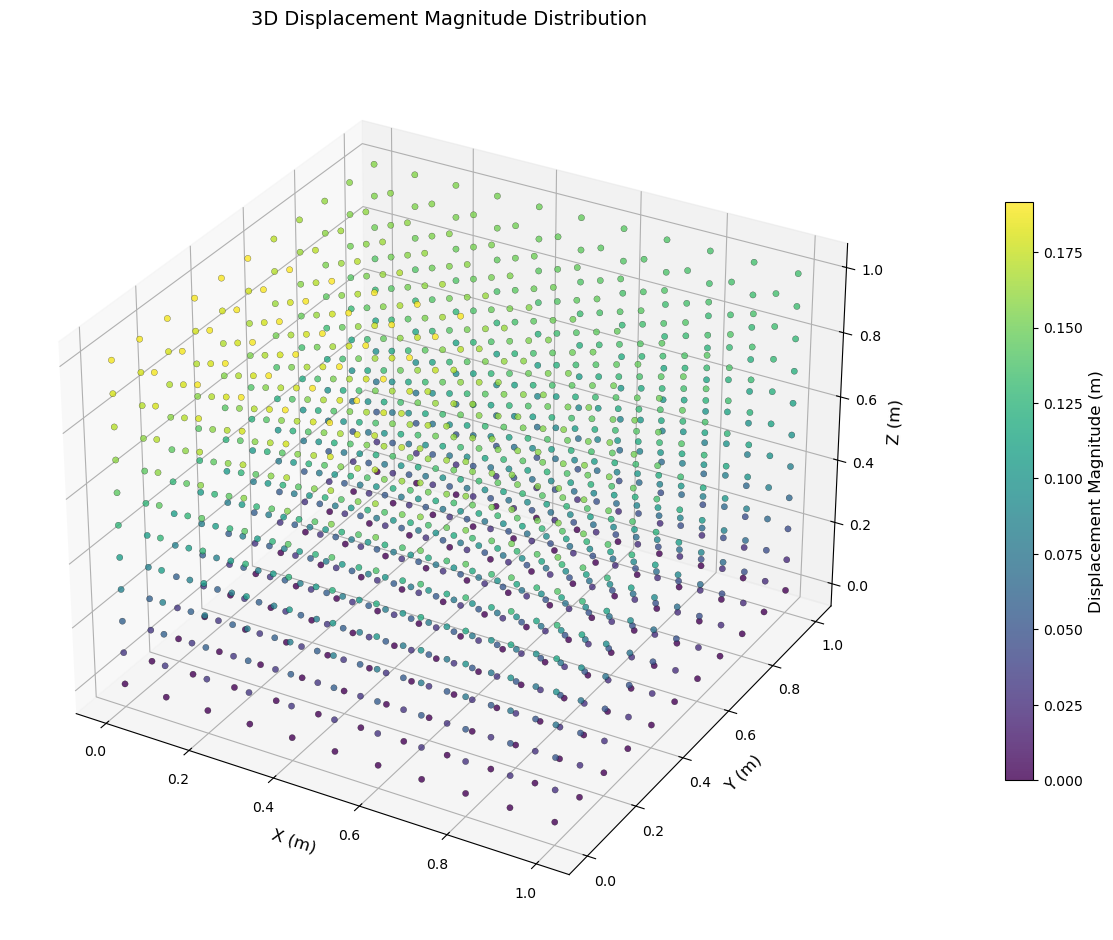

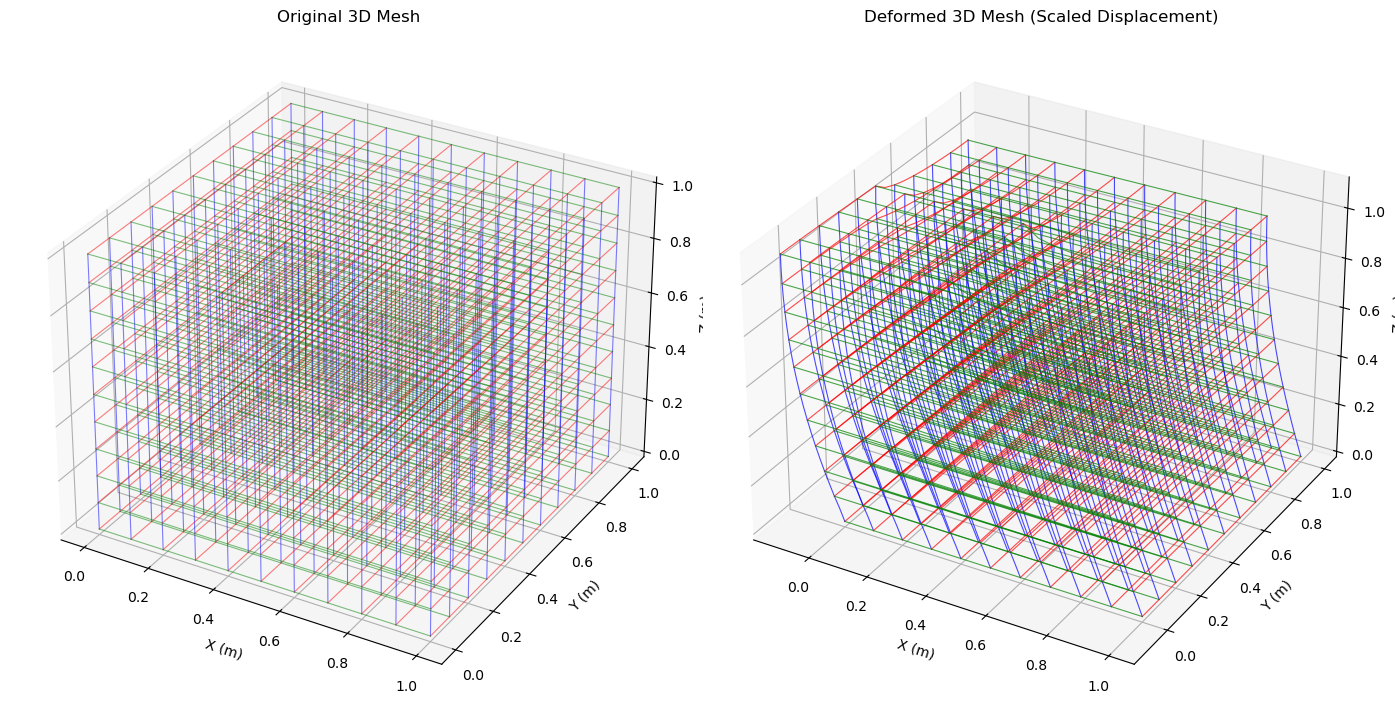

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -------------------------- 原有变量（ux, uy, uz, X, Y, Z 已定义） --------------------------
# 计算位移幅值
u_mag = np.sqrt(ux**2 + uy**2 + uz**2)

# 降采样步长（可根据N调整，N=21时step=2合适）
step = max(1, N // 10)
idx = slice(None, None, step)

# -------------------------- 1. 3D位移幅值云图（散点图） --------------------------
fig5 = plt.figure(figsize=(12, 10))
ax5 = fig5.add_subplot(111, projection='3d')

# 绘制降采样后的位移幅值散点
scatter = ax5.scatter(
    X[idx, idx, idx], Y[idx, idx, idx], Z[idx, idx, idx],
    c=u_mag[idx, idx, idx],  # 颜色映射为位移幅值
    cmap='viridis',          # 颜色方案（蓝→黄→绿，幅值从低到高）
    s=20,                    # 散点大小
    alpha=0.8,               # 透明度
    edgecolors='k',          # 散点边缘颜色
    linewidths=0.2
)

# 添加颜色条
cbar = fig5.colorbar(scatter, ax=ax5, shrink=0.6, pad=0.1)
cbar.set_label('Displacement Magnitude (m)', fontsize=12)

# 设置坐标轴和标题
ax5.set_xlabel('X (m)', fontsize=12)
ax5.set_ylabel('Y (m)', fontsize=12)
ax5.set_zlabel('Z (m)', fontsize=12)
ax5.set_title('3D Displacement Magnitude Distribution', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# -------------------------- 2. 3D变形网格对比图 --------------------------
fig6 = plt.figure(figsize=(14, 12))

# 子图1：原始网格
ax6_1 = fig6.add_subplot(121, projection='3d')
# 绘制x方向网格线
for i in range(0, N, step):
    for j in range(0, N, step):
        ax6_1.plot(X[i, j, :], Y[i, j, :], Z[i, j, :], 'b-', linewidth=0.8, alpha=0.5)
# 绘制y方向网格线
for i in range(0, N, step):
    for k in range(0, N, step):
        ax6_1.plot(X[i, :, k], Y[i, :, k], Z[i, :, k], 'r-', linewidth=0.8, alpha=0.5)
# 绘制z方向网格线
for j in range(0, N, step):
    for k in range(0, N, step):
        ax6_1.plot(X[:, j, k], Y[:, j, k], Z[:, j, k], 'g-', linewidth=0.8, alpha=0.5)
ax6_1.set_xlabel('X (m)')
ax6_1.set_ylabel('Y (m)')
ax6_1.set_zlabel('Z (m)')
ax6_1.set_title('Original 3D Mesh', fontsize=12)

# 子图2：变形后网格
ax6_2 = fig6.add_subplot(122, projection='3d')
# 计算变形后坐标
X_def = X + ux
Y_def = Y + uy
Z_def = Z + uz
# 绘制x方向变形网格线
for i in range(0, N, step):
    for j in range(0, N, step):
        ax6_2.plot(X_def[i, j, :], Y_def[i, j, :], Z_def[i, j, :], 'b-', linewidth=0.8, alpha=0.7)
# 绘制y方向变形网格线
for i in range(0, N, step):
    for k in range(0, N, step):
        ax6_2.plot(X_def[i, :, k], Y_def[i, :, k], Z_def[i, :, k], 'r-', linewidth=0.8, alpha=0.7)
# 绘制z方向变形网格线
for j in range(0, N, step):
    for k in range(0, N, step):
        ax6_2.plot(X_def[:, j, k], Y_def[:, j, k], Z_def[:, j, k], 'g-', linewidth=0.8, alpha=0.7)
ax6_2.set_xlabel('X (m)')
ax6_2.set_ylabel('Y (m)')
ax6_2.set_zlabel('Z (m)')
ax6_2.set_title('Deformed 3D Mesh (Scaled Displacement)', fontsize=12)

plt.tight_layout()
plt.show()